# Training a tiny neural network — from scratch, and hands-on

This notebook takes the plain-numpy training script (`train.py`) and turns it into
something you can **see** and **play with**.

We train a tiny neural network (one hidden layer) to predict whether a student is
**admitted** (1) or **not** (0) from two numbers:

| input | meaning |
|-------|---------|
| `hours_studied` | hours spent studying |
| `hours_slept`   | hours slept the night before |

Everything is written by hand with numpy — no PyTorch, no fastai. You can read
every line of the training loop and change things to see what happens.

**How to use this notebook:** run the cells top to bottom (Shift+Enter). The last
sections have **sliders** — drag them and the graphs redraw instantly.

## 1. Setup

Just the imports. `numpy` does the math, `matplotlib` draws the graphs, and
`ipywidgets` gives us the sliders.

In [1]:
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["figure.dpi"] = 100

# nice colours for the two classes (not-admitted, admitted)
CMAP_PTS = ListedColormap(["#e8623c", "#2a9d8f"])   # points
CMAP_BG  = ListedColormap(["#fbe3da", "#d6efeb"])    # decision-boundary fill
print("ready")

ready


## 2. Load and look at the data

`data.csv` has 80 students. Let's load it and take a peek.

In [2]:
def find_data():
    # Locate data.csv whether we run from the notebook folder or the repo root.
    for p in [Path("data.csv"), Path("simple_training/data.csv")]:
        if p.exists():
            return p
    raise FileNotFoundError("data.csv not found next to the notebook")

def load_csv(path):
    rows = list(csv.DictReader(open(path, newline="")))
    X = np.array([[float(r["hours_studied"]), float(r["hours_slept"])] for r in rows])
    y = np.array([[float(r["admitted"])] for r in rows])   # shape (n, 1)
    return X, y

X_raw, y = load_csv(find_data())
print(f"{X_raw.shape[0]} students, {X_raw.shape[1]} inputs each")
print(f"admitted: {int(y.sum())}   not admitted: {int((1 - y).sum())}")

# show the first few rows as a quick table
print("\n hours_studied  hours_slept  admitted")
for (hs, hl), a in zip(X_raw[:8], y[:8]):
    print(f"      {hs:5.2f}        {hl:5.2f}        {int(a[0])}")

80 students, 2 inputs each
admitted: 54   not admitted: 26

 hours_studied  hours_slept  admitted
       7.74         6.99        1
       4.39         5.44        0
       8.59         7.88        1
       6.97         4.00        1
       0.94         3.14        0
       9.76         3.54        1
       7.61         7.33        1
       7.86         5.77        1


### See it as a picture

Each student is one dot: **x = hours studied**, **y = hours slept**. Green dots were
admitted, orange were not. Already you can eyeball the pattern — studying more pushes
you toward "admitted".

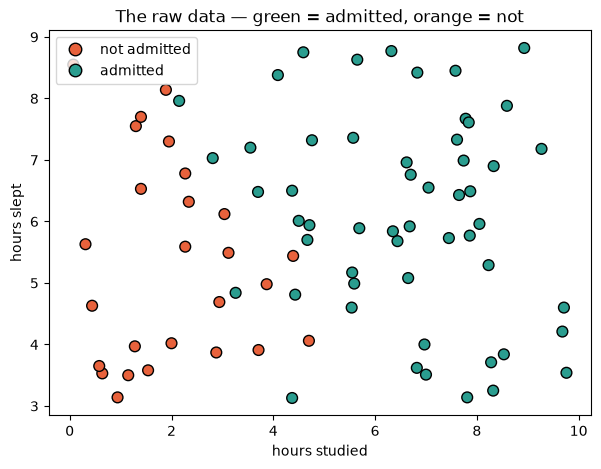

In [3]:
fig, ax = plt.subplots()
sc = ax.scatter(X_raw[:, 0], X_raw[:, 1], c=y.ravel(), cmap=CMAP_PTS,
                edgecolors="k", s=60)
ax.set_xlabel("hours studied")
ax.set_ylabel("hours slept")
ax.set_title("The raw data — green = admitted, orange = not")
handles = [plt.Line2D([], [], marker="o", ls="", mec="k", mfc=c, ms=9)
           for c in ["#e8623c", "#2a9d8f"]]
ax.legend(handles, ["not admitted", "admitted"], loc="upper left")
plt.show()

## 3. The building blocks

Two small helpers do a lot of work.

**`sigmoid`** squashes any number into the range (0, 1) so we can read the model's
output as a *probability*. Big positive input → close to 1 ("yes, admitted"), big
negative → close to 0.

**`normalize`** rescales each input column to mean 0, std 1. Training is much easier
when both inputs are on a similar scale.

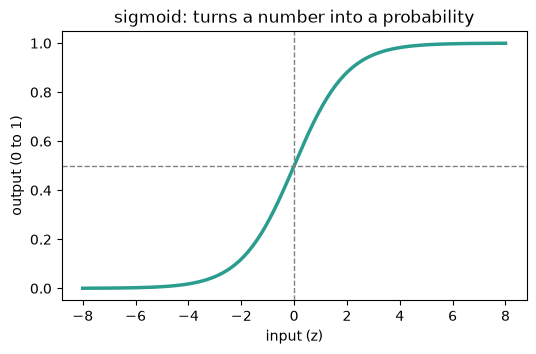

normalized inputs -> mean: [0. 0.]  std: [1. 1.]


In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def normalize(X):
    mean, std = X.mean(axis=0), X.std(axis=0)
    return (X - mean) / std, mean, std

# plot the sigmoid so its shape is concrete
z = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(z, sigmoid(z), color="#2a9d8f", lw=2.5)
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_title("sigmoid: turns a number into a probability")
ax.set_xlabel("input (z)"); ax.set_ylabel("output (0 to 1)")
plt.show()

X, mean, std = normalize(X_raw)   # normalized inputs used for training
print("normalized inputs -> mean:", X.mean(axis=0).round(3), " std:", X.std(axis=0).round(3))

## 4. The model, in one breath

The network has exactly two layers:

```
inputs (2)  ->  hidden layer (H units, ReLU)  ->  output (1, sigmoid) = probability
```

Training repeats four steps, `EPOCHS` times:

1. **Forward pass** — run the inputs through the network to get a prediction.
2. **Loss** — measure how wrong the predictions are (binary cross-entropy).
3. **Backward pass** — use the chain rule to find which direction each weight should move.
4. **Step** — nudge every weight a little bit downhill (that's the `LEARNING_RATE`).

The function below is exactly the loop from `train.py`, with one addition: it
**records the loss and accuracy at every epoch** so we can plot the learning curve.

In [5]:
def train(X, y, hidden_units=8, learning_rate=0.1, epochs=400, seed=0):
    # Train the tiny net; return learned weights + a history of loss/accuracy.
    rng = np.random.default_rng(seed)
    n_samples, n_features = X.shape

    # initialise weights from scratch
    W1 = rng.normal(0, 0.5, size=(n_features, hidden_units))
    b1 = np.zeros((1, hidden_units))
    W2 = rng.normal(0, 0.5, size=(hidden_units, 1))
    b2 = np.zeros((1, 1))

    hist = {"loss": [], "acc": []}
    for epoch in range(epochs):
        # forward
        z1 = X @ W1 + b1
        a1 = np.maximum(0, z1)          # ReLU
        z2 = a1 @ W2 + b2
        preds = sigmoid(z2)

        # loss (binary cross-entropy)
        eps = 1e-8
        loss = -np.mean(y * np.log(preds + eps) + (1 - y) * np.log(1 - preds + eps))

        # backward (gradients via chain rule)
        dz2 = (preds - y) / n_samples
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)
        da1 = dz2 @ W2.T
        dz1 = da1 * (z1 > 0)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        # gradient-descent step
        W2 -= learning_rate * dW2; b2 -= learning_rate * db2
        W1 -= learning_rate * dW1; b1 -= learning_rate * db1

        hist["loss"].append(loss)
        hist["acc"].append(float(((preds > 0.5) == (y > 0.5)).mean()))

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}, hist

def predict(model, X):
    # Probability of 'admitted' for each row of (normalized) X.
    a1 = np.maximum(0, X @ model["W1"] + model["b1"])
    return sigmoid(a1 @ model["W2"] + model["b2"])

print("train() and predict() defined")

train() and predict() defined


## 5. Train it once and watch it learn

Two curves tell the whole story:

- **Loss** should slide *down* — the model is getting less wrong.
- **Accuracy** should climb *up* toward 100%.

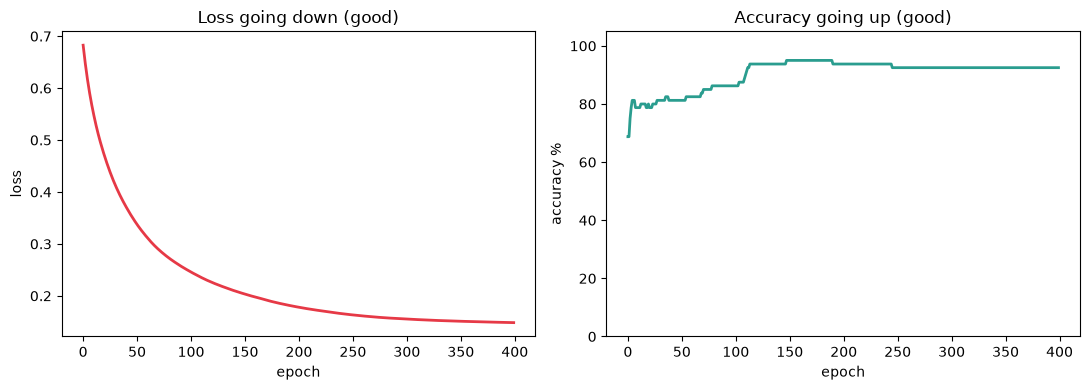

final loss 0.1484   final accuracy 92.5%


In [6]:
model, hist = train(X, y, hidden_units=8, learning_rate=0.1, epochs=400, seed=0)

fig, (axL, axA) = plt.subplots(1, 2, figsize=(11, 4))
axL.plot(hist["loss"], color="#e63946", lw=2)
axL.set_title("Loss going down (good)"); axL.set_xlabel("epoch"); axL.set_ylabel("loss")
axA.plot(np.array(hist["acc"]) * 100, color="#2a9d8f", lw=2)
axA.set_title("Accuracy going up (good)"); axA.set_xlabel("epoch"); axA.set_ylabel("accuracy %")
axA.set_ylim(0, 105)
plt.tight_layout(); plt.show()

print(f"final loss {hist['loss'][-1]:.4f}   final accuracy {hist['acc'][-1]:.1%}")

## 6. What did it actually learn? — the decision boundary

We can colour the whole input space by what the model predicts. The shaded regions
are where it says "admitted" (green) vs "not" (orange). The dots are the real
students. Where a dot's colour matches its background, the model got it right.

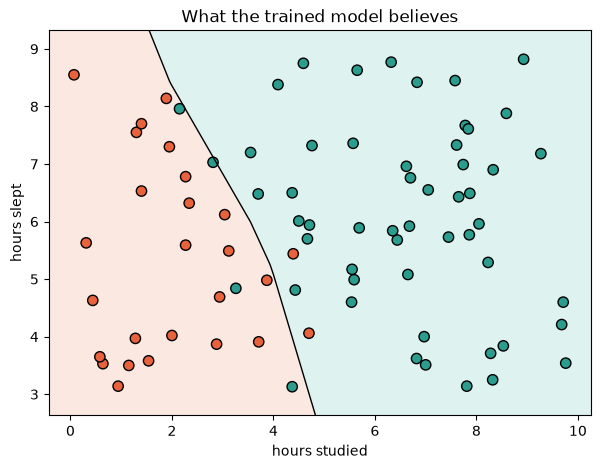

In [7]:
def plot_decision_boundary(model, ax=None, title="Decision boundary"):
    if ax is None:
        _, ax = plt.subplots()
    # grid over the ORIGINAL (hours) space
    xs = np.linspace(X_raw[:, 0].min() - 0.5, X_raw[:, 0].max() + 0.5, 200)
    ys = np.linspace(X_raw[:, 1].min() - 0.5, X_raw[:, 1].max() + 0.5, 200)
    gx, gy = np.meshgrid(xs, ys)
    grid = np.c_[gx.ravel(), gy.ravel()]
    grid_norm = (grid - mean) / std          # normalize the same way as training
    probs = predict(model, grid_norm).reshape(gx.shape)

    ax.contourf(gx, gy, probs, levels=[0, 0.5, 1], cmap=CMAP_BG, alpha=0.8)
    ax.contour(gx, gy, probs, levels=[0.5], colors="k", linewidths=1)
    ax.scatter(X_raw[:, 0], X_raw[:, 1], c=y.ravel(), cmap=CMAP_PTS,
               edgecolors="k", s=55)
    ax.set_xlabel("hours studied"); ax.set_ylabel("hours slept"); ax.set_title(title)
    return ax

plot_decision_boundary(model, title="What the trained model believes")
plt.show()

## 7. 🎛️ Play with the training knobs

This is the fun part. Drag the sliders and everything **retrains and redraws**:

- **hidden units** — the model's capacity. Too few (1) can't bend the boundary; more
  lets it curve.
- **learning rate** — step size. Too small = learns slowly; too big = unstable, loss
  can jump around.
- **epochs** — how many passes over the data. More = more learning (up to a point).
- **seed** — the random starting weights. Shows how much luck is involved.

Watch the loss curve *and* the decision boundary react together.

In [ ]:
def explore(hidden_units, learning_rate, epochs, seed):
    model, hist = train(X, y, hidden_units, learning_rate, epochs, seed)

    fig, (axL, axB) = plt.subplots(1, 2, figsize=(12, 4.5))
    axL.plot(hist["loss"], color="#e63946", lw=2)
    axL.set_title(f"Loss  (final {hist['loss'][-1]:.3f})")
    axL.set_xlabel("epoch"); axL.set_ylabel("loss"); axL.set_ylim(bottom=0)

    plot_decision_boundary(model, ax=axB,
                           title=f"Decision boundary  (accuracy {hist['acc'][-1]:.0%})")
    plt.tight_layout(); plt.show()

interact(
    explore,
    hidden_units=IntSlider(value=8, min=1, max=32, step=1, description="hidden units"),
    learning_rate=FloatSlider(value=0.1, min=0.001, max=1.5, step=0.001,
                              readout_format=".3f", description="learn rate"),
    epochs=IntSlider(value=400, min=10, max=3000, step=10, description="epochs"),
    seed=IntSlider(value=0, min=0, max=20, step=1, description="seed"),
);

interactive(children=(IntSlider(value=8, description='hidden units', max=32, min=1), FloatSlider(value=0.1, de…

**Things to try**

- Set **hidden units = 1**: the boundary can only be a straight line.
- Crank **learning rate** up to ~1.4: watch the loss curve get jumpy or blow up.
- Set **learning rate** very low (0.005) with 400 epochs: it barely learns — give it
  more epochs.
- Change only the **seed**: same settings, different luck at the start.

## 8. 🎓 Ask the model about one student

Train once with sensible settings, then move the two sliders to describe a student.
The gauge shows the model's predicted probability of being admitted.

In [9]:
trained, _ = train(X, y, hidden_units=8, learning_rate=0.1, epochs=800, seed=0)

def ask(hours_studied, hours_slept):
    x = (np.array([[hours_studied, hours_slept]]) - mean) / std
    p = float(predict(trained, x)[0, 0])

    fig, (axP, axB) = plt.subplots(1, 2, figsize=(12, 4.5),
                                   gridspec_kw={"width_ratios": [1, 1.4]})
    # probability bar
    axP.barh([0], [p], color="#2a9d8f" if p >= 0.5 else "#e8623c", height=0.5)
    axP.set_xlim(0, 1); axP.set_ylim(-1, 1); axP.set_yticks([])
    axP.axvline(0.5, color="gray", ls="--")
    axP.set_title(f"admitted probability: {p:.0%}")
    axP.text(p, 0.6, f"{p:.0%}", ha="center", fontsize=13, fontweight="bold")

    # where this student sits on the map
    plot_decision_boundary(trained, ax=axB, title="this student (★) on the map")
    axB.scatter([hours_studied], [hours_slept], marker="*", s=420,
                color="gold", edgecolors="k", zorder=5)
    plt.tight_layout(); plt.show()

    verdict = "ADMITTED" if p >= 0.5 else "NOT admitted"
    print(f"studied {hours_studied}h, slept {hours_slept}h  ->  {verdict}  ({p:.1%})")

interact(
    ask,
    hours_studied=FloatSlider(value=6, min=0, max=12, step=0.1, description="studied (h)"),
    hours_slept=FloatSlider(value=6, min=0, max=12, step=0.1, description="slept (h)"),
);

interactive(children=(FloatSlider(value=6.0, description='studied (h)', max=12.0), FloatSlider(value=6.0, desc…

## 9. Recap

You just trained a neural network from scratch and poked at every knob:

- A **forward pass** turns inputs into a probability.
- The **loss** measures how wrong that is; the **backward pass** finds which way to
  fix each weight; the **step** applies the fix. Repeat.
- **Hidden units** control how curvy the decision boundary can get.
- **Learning rate** controls step size — the single most finicky knob.
- **Epochs** control how long you train.

Same math as the big frameworks — just small enough to read in one sitting. Try
editing `train()` itself: swap ReLU for something else, add a second hidden layer,
or change the loss, and rerun the sliders.